In [3]:
!pip install cassandra-driver

In [1]:
from cassandra.cluster import Cluster

try:
    # Kết nối qua localhost vì dùng Anaconda trên Windows
    cluster = Cluster(['127.0.0.1'], port=9042)
    session = cluster.connect('project_ks')
    
    print(">>> Kết nối thành công trên Python 3.10.11!")
    
    # Truy vấn dữ liệu cho mục 4.3
    query = "SELECT brand, total_revenue FROM brand_stats"
    rows = session.execute(query)
    
    print("\n--- Dữ liệu Real-time ---")
    for row in rows:
        print(f"Thương hiệu: {row.brand} | Doanh thu: {row.total_revenue}")
        
except Exception as e:
    print(f">>> Lỗi rồi : {e}")

>>> Kết nối thành công trên Python 3.10.11!

--- Dữ liệu Real-time ---
Thương hiệu: 1683 | Doanh thu: 1683.0
Thương hiệu: 1424 | Doanh thu: 1424.0
Thương hiệu: 1615 | Doanh thu: 1615.0
Thương hiệu: 631 | Doanh thu: 631.0
Thương hiệu: 403 | Doanh thu: 403.0
Thương hiệu: 492 | Doanh thu: 492.0
Thương hiệu: 517 | Doanh thu: 517.0
Thương hiệu: 789 | Doanh thu: 789.0
Thương hiệu: 947 | Doanh thu: 947.0
Thương hiệu: 255 | Doanh thu: 255.0
Thương hiệu: 326 | Doanh thu: 326.0
Thương hiệu: 374 | Doanh thu: 374.0
Thương hiệu: 151 | Doanh thu: 151.0
Thương hiệu: 837 | Doanh thu: 837.0
Thương hiệu: 1019 | Doanh thu: 1019.0
Thương hiệu: 1529 | Doanh thu: 1529.0
Thương hiệu: 840 | Doanh thu: 840.0
Thương hiệu: 1123 | Doanh thu: 1123.0
Thương hiệu: 1272 | Doanh thu: 1272.0
Thương hiệu: 560 | Doanh thu: 560.0
Thương hiệu: 925 | Doanh thu: 925.0
Thương hiệu: 1194 | Doanh thu: 1194.0
Thương hiệu: 554 | Doanh thu: 554.0
Thương hiệu: 1548 | Doanh thu: 1548.0
Thương hiệu: 6 | Doanh thu: 6.0
Thương hiệu: 13

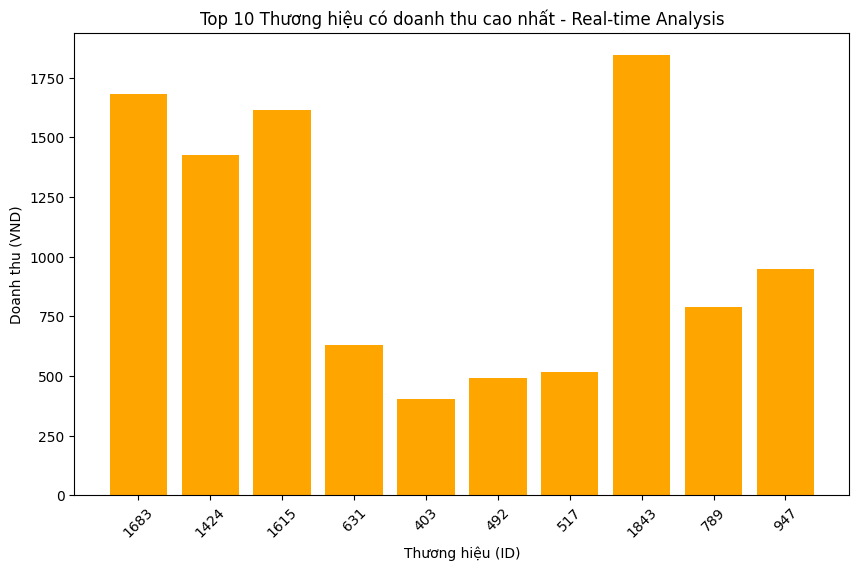

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Lấy dữ liệu từ kết quả truy vấn vừa rồi
query = "SELECT brand, total_revenue FROM brand_stats"
rows = session.execute(query)
df = pd.DataFrame(rows)

# Chỉ lấy 10 thương hiệu đầu tiên cho biểu đồ đỡ bị rối
df_plot = df.head(10)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(df_plot['brand'], df_plot['total_revenue'], color='orange')
plt.xlabel('Thương hiệu (ID)')
plt.ylabel('Doanh thu (VND)')
plt.title('Top 10 Thương hiệu có doanh thu cao nhất - Real-time Analysis')
plt.xticks(rotation=45)
plt.show()